# Hardware Pulse: Exploratory Data Analysis

This notebook analyzes the data collected by the hardware-pulse pipeline.
It is designed to scale automatically with more data: early sections
work with any amount of data, sections 6-7 are enriched with historical data.

**Sources:**
- `raw_listings`: raw scraper data (sections 1-3)
- `price_snapshots`: normalized post-resolution data (sections 4-7)

## Setup

In [17]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

In [18]:
# --- Config ---
DB_PATH = Path("../data/hardware_pulse.db")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

In [19]:
# --- Load data ---
conn = sqlite3.connect(DB_PATH)

df_raw = pd.read_sql_query("SELECT * FROM raw_listings", conn)

# Detect if price_snapshots has data
snapshot_count = pd.read_sql_query(
    "SELECT COUNT(*) as n FROM price_snapshots", conn
).iloc[0]["n"]

if snapshot_count > 0:
    df_snap = pd.read_sql_query("SELECT * FROM price_snapshots", conn)
    HAS_SNAPSHOTS = True
    print(f"✅ price_snapshots available: {snapshot_count} rows")
else:
    df_snap = pd.DataFrame()
    HAS_SNAPSHOTS = False
    print("⚠️  price_snapshots empty, sections 4-7 will use on-the-fly resolution")

conn.close()

✅ price_snapshots available: 234 rows


In [20]:
# --- Parse timestamps ---
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"], utc=True)
df_raw["run_date"] = df_raw["timestamp"].dt.date

if HAS_SNAPSHOTS:
    df_snap["timestamp"] = pd.to_datetime(df_snap["timestamp"], utc=True)
    df_snap["run_date"] = df_snap["timestamp"].dt.date

print(f"\nraw_listings: {len(df_raw)} rows")
if HAS_SNAPSHOTS:
    print(f"price_snapshots: {len(df_snap)} rows")


raw_listings: 345 rows
price_snapshots: 234 rows


---
## Section 1: Basic Sanity Check
*Works with any amount of data*

In [21]:
print("=== Shape ===")
print(f"Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}")

print("\n=== Null Values ===")
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else "No null values in key columns")

print("\n=== Count by source ===")
display(df_raw["source"].value_counts(dropna=False).rename("count"))

print("\n=== Count by run_date ===")
display(df_raw["run_date"].value_counts().sort_index().rename("listings"))

print("\n=== Currency distribution ===")
display(df_raw["currency"].value_counts(dropna=False).rename("count"))

print("\n=== Condition distribution ===")
display(df_raw["condition"].value_counts(dropna=False).rename("count"))

=== Shape ===
Rows: 345 | Columns: 16

=== Null Values ===
item_id               345
available_quantity    345
base_price            345

=== Count by source ===


source
thot       140
banifox    139
pccompu     66
Name: count, dtype: int64


=== Count by run_date ===


run_date
2026-04-24    308
2026-04-26     30
2026-04-28      5
2026-04-29      1
2026-04-30      1
Name: listings, dtype: int64


=== Currency distribution ===


currency
USD    345
Name: count, dtype: int64


=== Condition distribution ===


condition
new    345
Name: count, dtype: int64

In [22]:
# Unique listings vs total
print(f"Unique URLs:   {df_raw['url'].nunique():,}")
print(f"Unique titles: {df_raw['title'].nunique():,}")
print(f"Total rows:   {len(df_raw):,}")

print("\n=== Time range ===")
print(f"First record: {df_raw['timestamp'].min()}")
print(f"Last record:  {df_raw['timestamp'].max()}")
print(f"Days covered: {df_raw['run_date'].nunique()}")

Unique URLs:   345
Unique titles: 345
Total rows:   345

=== Time range ===
First record: 2026-04-24 21:16:19.477725+00:00
Last record:  2026-04-30 21:32:01.116219+00:00
Days covered: 5


---
## Section 2: Price Quality
*Works with any amount of data*

In [23]:
print("=== Price Statistics ===")
display(df_raw["price"].describe().round(2))

# Obvious outliers
outliers = df_raw[(df_raw["price"] < 10) | (df_raw["price"] > 10_000)]
print(f"\nOutliers (price < 10 or > 10,000 USD): {len(outliers)} records")
if len(outliers) > 0:
    display(outliers[["title", "price", "currency", "source"]].head(10))

=== Price Statistics ===


count     345.00
mean      531.89
std       535.16
min         3.00
25%       238.00
50%       425.00
75%       672.00
max      6159.00
Name: price, dtype: float64


Outliers (price < 10 or > 10,000 USD): 4 records


,title,price,currency,source
55,Pasta termica Deep Cool Z3,5.0,USD,thot
56,Pasta térmica Cooler Master RPD Grease High Pe...,6.0,USD,thot
57,Pasta termica Deep Cool Z5,7.0,USD,thot
332,Micro Procesador CPU Intel Dual Core E5800 Soc...,3.0,USD,pccompu


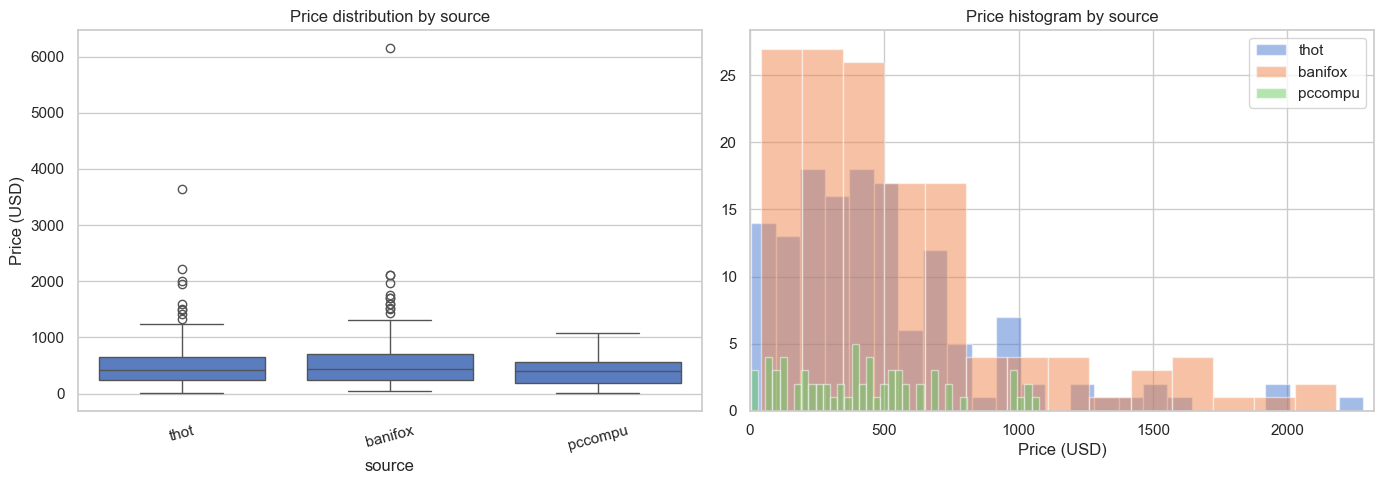

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot by source
sns.boxplot(data=df_raw, x="source", y="price", ax=axes[0])
axes[0].set_title("Price distribution by source")
axes[0].set_ylabel("Price (USD)")
axes[0].tick_params(axis="x", rotation=15)

# Histogram by source
for source in df_raw["source"].unique():
    subset = df_raw[df_raw["source"] == source]["price"]
    axes[1].hist(subset, bins=40, alpha=0.5, label=source)
axes[1].set_title("Price histogram by source")
axes[1].set_xlabel("Price (USD)")
axes[1].set_xlim(0, df_raw["price"].quantile(0.99) * 1.1)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Section 3: Title Analysis
*Works with any amount of data*

In [25]:
import re
import sys
sys.path.insert(0, "..")

# Title length
df_raw["title_len"] = df_raw["title"].str.len()
print("=== Title Length ===")
display(df_raw["title_len"].describe().round(1))

# Basic GPU detection by keywords
GPU_PATTERN = re.compile(r"RTX|RX\s?\d|Arc\s?[AB]|Radeon|GeForce|GTX", re.IGNORECASE)
df_raw["is_gpu"] = df_raw["title"].str.contains(GPU_PATTERN, regex=True)

total = len(df_raw)
gpu_count = df_raw["is_gpu"].sum()
print(f"\nTitles with GPU keywords: {gpu_count} / {total} ({100*gpu_count/total:.1f}%)")
print(f"Titles without GPU keywords: {total - gpu_count} ({100*(total-gpu_count)/total:.1f}%)")

=== Title Length ===


count    345.0
mean      46.1
std       18.1
min       20.0
25%       33.0
50%       41.0
75%       53.0
max      105.0
Name: title_len, dtype: float64


Titles with GPU keywords: 146 / 345 (42.3%)
Titles without GPU keywords: 199 (57.7%)


In [26]:
print("=== Sample titles by source ===")
for source in df_raw["source"].unique():
    print(f"\n--- {source.upper()} ---")
    display(df_raw[df_raw["source"] == source]["title"].head(8).reset_index(drop=True))

print("\n=== Titles without GPU keywords (possible noise) ===")
display(
    df_raw[~df_raw["is_gpu"]][["title", "source", "price"]]
    .head(15)
    .reset_index(drop=True)
)

=== Sample titles by source ===

--- THOT ---


0    Antec Riser Cable Vertical GPU AT-RCVB-BK200-P...
1    Antec Riser Cable Vertical GPU AT-RCVB-W200-PC...
2                         MSI GeForce G210 1Gb Ddr3 LP
3                   GPU Biostar GeForce G210 1Gb GDDR3
4                        Biostar Radeon RX550 4gb ddr5
5            GPU Palit GeForce RTX3050 Stormx 6GB DDR6
6              GPU MSI GeForce RTX 3050 LP OC 6Gb DDR6
7        GPU Gigabyte GeForce RTX3050 Windforce OC 6Gb
Name: title, dtype: str


--- BANIFOX ---


0            AMD XFX RADEON RX 9070 PRO GAMING 16GB OC
1                               ASUS DUAL-RX9060XT-16G
2    ASUS GEFORCE RTX4070 OC ROG-STRIX-RTX4070-O12G...
3                    ASUS PRIME RADEON RX9070-O16G-EVO
4                             BIOSTAR GEFORCE G210 1GB
5                            BIOSTAR GEFORCE GT610 2GB
6         BIOSTAR RADEON RX550 4GB VA5505RF41SBHRA-BS2
7                 BIOSTAR RADEON RX580 2048SP 8GB DDR5
Name: title, dtype: str


--- PCCOMPU ---


0    Tarjeta de Video Palit StormX Nvidia GeForce R...
1    Tarjeta de Video Biostar AMD Radeon RX 580 8GB...
2    Tarjeta de Video Zotac Nvidia GeForce RTX 5060...
3    Tarjeta de Video Gigabyte AMD Radeon RX 9070 G...
4    Tarjeta de Video Palit Nvidia GeForce RTX 3050...
5    Tarjeta de Video XFX Swift AMD Radeon RX 9060 ...
6    Tarjeta de Video ASRock AMD Radeon RX 9060 XT ...
7    Tarjeta de Video ASRock Intel ARC B580 Challen...
Name: title, dtype: str


=== Titles without GPU keywords (possible noise) ===


,title,source,price
0,Pasta termica Deep Cool Z3,thot,5.00
1,Pasta térmica Cooler Master RPD Grease High Pe...,thot,6.00
2,Pasta termica Deep Cool Z5,thot,7.00
3,"Pasta térmica Deep Cool DM9 1,5g",thot,10.00
4,Pasta Térmica Cooler Master CRYOFUZE 5,thot,11.99
5,Pasta térmica Deep Cool DM9 4g,thot,17.49
6,CPU AMD Athlon 3000G,thot,49.00
7,CPU AMD Ryzen 5 3400G AM4,thot,89.00
8,Intel Core i3 10100f 3.60GHz 6MB LGA1200 10th Gen,thot,95.00
9,CPU Intel Core i3 10105f 3.60GHz 6MB LGA1200 1...,thot,99.00


---
## Sección 4: Salud del Matching / Resolución
*Usa price_snapshots si disponible, resolución on-the-fly si no*

In [27]:
from src.entities.catalog import load_catalog
from src.entities.resolver import resolve_batch
from src.domain.models import RawListing, Source, Currency, Condition

catalog = load_catalog()

if HAS_SNAPSHOTS:
    # Use already processed snapshots
    matched = len(df_snap)
    total = len(df_raw)
    unmatched = total - matched
    print(f"✅ Using existing price_snapshots")
    print(f"Total raw listings: {total}")
    print(f"Matched:            {matched} ({100*matched/total:.1f}%)")
    print(f"Unmatched:          {unmatched} ({100*unmatched/total:.1f}%)")
    
    print("\n=== Distribution of matched_by (on snapshots not available, resolve on-the-fly for this) ===")
else:
    # Resolve on-the-fly for analysis
    listings = []
    for _, row in df_raw.iterrows():
        try:
            listings.append(RawListing(
                source=Source(row["source"]),
                url=row["url"],
                timestamp=row["timestamp"],
                title=row["title"],
                price=float(row["price"]),
                currency=Currency(row["currency"]),
                seller=row["seller"],
                condition=Condition(row["condition"]) if row["condition"] else None,
            ))
        except Exception:
            pass
    
    resolved = resolve_batch(listings, catalog)
    matched = sum(1 for r in resolved if r.canonical_product_id is not None)
    unmatched = len(resolved) - matched
    print(f"Total: {len(resolved)} | Matched: {matched} | Unmatched: {unmatched}")

✅ Using existing price_snapshots
Total raw listings: 345
Matched:            234 (67.8%)
Unmatched:          111 (32.2%)

=== Distribution of matched_by (on snapshots not available, resolve on-the-fly for this) ===


In [28]:
# Always resolve on-the-fly for matched_by and confidence analysis
listings_for_analysis = []
for _, row in df_raw.iterrows():
    try:
        listings_for_analysis.append(RawListing(
            source=Source(row["source"]),
            url=row["url"],
            timestamp=row["timestamp"],
            title=row["title"],
            price=float(row["price"]),
            currency=Currency(row["currency"]),
            seller=row["seller"],
            condition=Condition(row["condition"]) if row["condition"] else None,
        ))
    except Exception:
        pass

resolved_all = resolve_batch(listings_for_analysis, catalog)
df_resolved = pd.DataFrame([
    {
        "title": r.title,
        "canonical_product_id": r.canonical_product_id,
        "matched_by": r.matched_by or "none",
        "confidence_score": r.confidence_score,
        "brand": r.brand,
        "source": r.source.value,
    }
    for r in resolved_all
])

print("=== Distribution of matched_by ===")
display(df_resolved["matched_by"].value_counts())

print("\n=== Top 15 canonical_product_id ===")
display(df_resolved[df_resolved["canonical_product_id"].notna()]["canonical_product_id"].value_counts().head(15))

print("\n=== Examples without match ===")
display(
    df_resolved[df_resolved["canonical_product_id"].isna()][["title", "source"]]
    .head(10)
    .reset_index(drop=True)
)

=== Distribution of matched_by ===


matched_by
none     227
exact    115
regex      3
Name: count, dtype: int64


=== Top 15 canonical_product_id ===


canonical_product_id
RTX 5060      25
RX 9060 XT    20
RTX 5070      20
RTX 3050      11
RX 9070        8
RTX 5050       7
RX 9070 XT     6
RTX 5080       6
RX 7600        5
Arc A580       2
Arc B570       2
Arc B580       2
RTX 5090       2
RTX 4070       1
RTX 4080       1
Name: count, dtype: int64


=== Examples without match ===


,title,source
0,Antec Riser Cable Vertical GPU AT-RCVB-BK200-P...,thot
1,Antec Riser Cable Vertical GPU AT-RCVB-W200-PC...,thot
2,MSI GeForce G210 1Gb Ddr3 LP,thot
3,GPU Biostar GeForce G210 1Gb GDDR3,thot
4,Biostar Radeon RX550 4gb ddr5,thot
5,Pasta termica Deep Cool Z3,thot
6,Pasta térmica Cooler Master RPD Grease High Pe...,thot
7,Pasta termica Deep Cool Z5,thot
8,"Pasta térmica Deep Cool DM9 1,5g",thot
9,Pasta Térmica Cooler Master CRYOFUZE 5,thot


---
## Section 5: Price Dispersion by SKU and Source
*Requires price_snapshots - improves with more SKUs and dates*

In [29]:
if not HAS_SNAPSHOTS:
    print("⚠️  No price_snapshots available. Run run_resolve.py first.")
else:
    # Statistics by SKU
    sku_stats = (
        df_snap.groupby("canonical_product_id")["price_usd"]
        .agg(["count", "min", "median", "max", "std"])
        .round(2)
        .sort_values("count", ascending=False)
    )
    sku_stats.columns = ["listings", "min_usd", "median_usd", "max_usd", "std_usd"]
    print("=== Price statistics by SKU ===")
    display(sku_stats)

=== Price statistics by SKU ===


,listings,min_usd,median_usd,max_usd,std_usd
canonical_product_id,,,,,
RTX 5060,50,524.99,625.00,825.0,88.10
RX 9060 XT,40,499.00,649.00,769.0,89.45
RTX 5070,38,980.00,1324.99,1709.0,267.12
RTX 3050,22,267.00,292.00,390.0,43.06
RX 9070,16,918.00,980.00,1000.0,24.87
RTX 5050,14,395.00,425.00,449.0,15.79
RX 9070 XT,12,1075.00,1234.00,1240.0,62.08
RTX 5080,12,1950.00,2051.50,2225.0,100.41
RX 7600,10,399.00,425.00,465.0,22.96


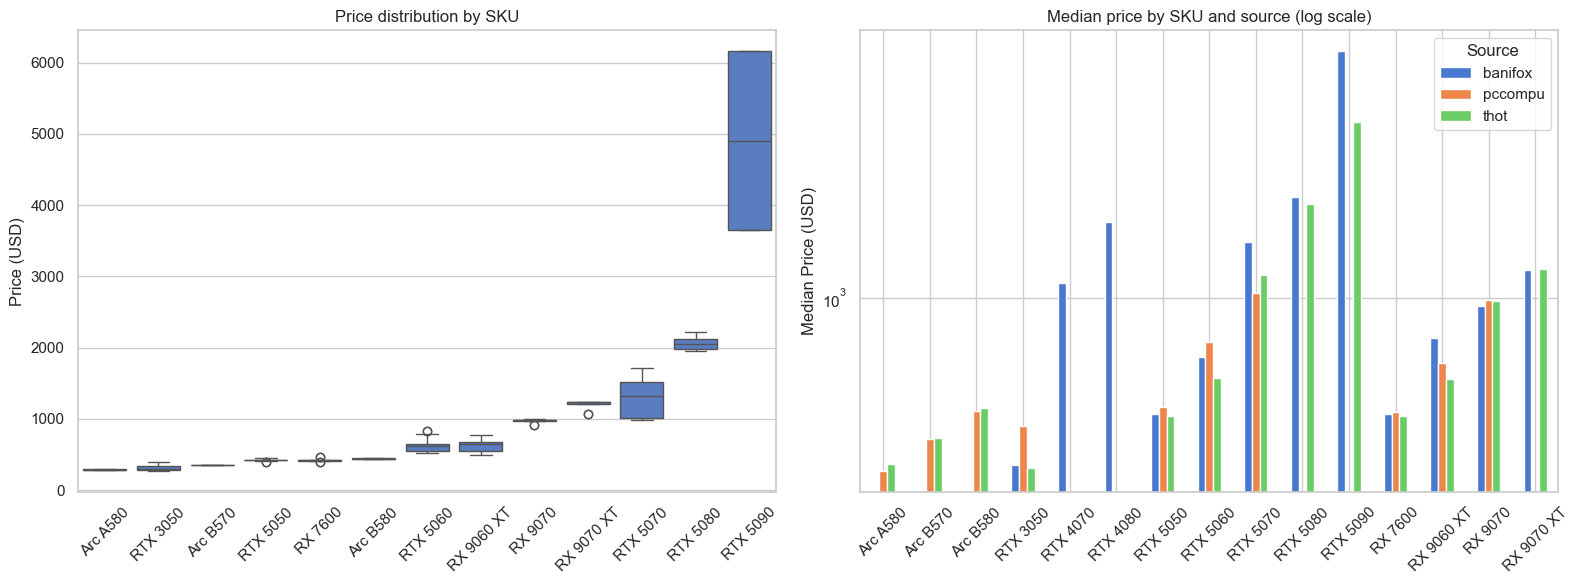

In [41]:
if HAS_SNAPSHOTS and len(df_snap) > 0:
    # Top SKUs with sufficient listings
    top_skus = sku_stats[sku_stats["listings"] >= 3].index.tolist()
    df_top = df_snap[df_snap["canonical_product_id"].isin(top_skus)]

    if len(df_top) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Boxplot price by SKU
        sku_order = sku_stats.loc[top_skus, "median_usd"].sort_values().index
        sns.boxplot(
            data=df_top,
            x="canonical_product_id",
            y="price_usd",
            order=sku_order,
            ax=axes[0]
        )
        axes[0].set_title("Price distribution by SKU")
        axes[0].set_xlabel("")
        axes[0].set_ylabel("Price (USD)")
        axes[0].tick_params(axis="x", rotation=45)

        # Dispersion by source for each SKU
        source_sku = (
            df_snap.groupby(["canonical_product_id", "source"])["price_usd"]
            .agg(["count", "median"])
            .reset_index()
        )
        pivot = source_sku.pivot(index="canonical_product_id", columns="source", values="median")
        pivot.plot(kind="bar", ax=axes[1], rot=45)
        axes[1].set_title("Median price by SKU and source (log scale)")
        axes[1].set_ylabel("Median Price (USD)")
        axes[1].set_xlabel("")
        axes[1].set_yscale("log")
        axes[1].legend(title="Source")

        plt.tight_layout()
        plt.show()
    else:
        print("No SKUs with 3+ listings yet.")

---
## Section 6: Temporal Trends
*Requires several weeks of history to be significant*

Days of history available: 2
⚠️  Less than 7 days of history. This section will improve with more data.
     Showing initial trend with available data...


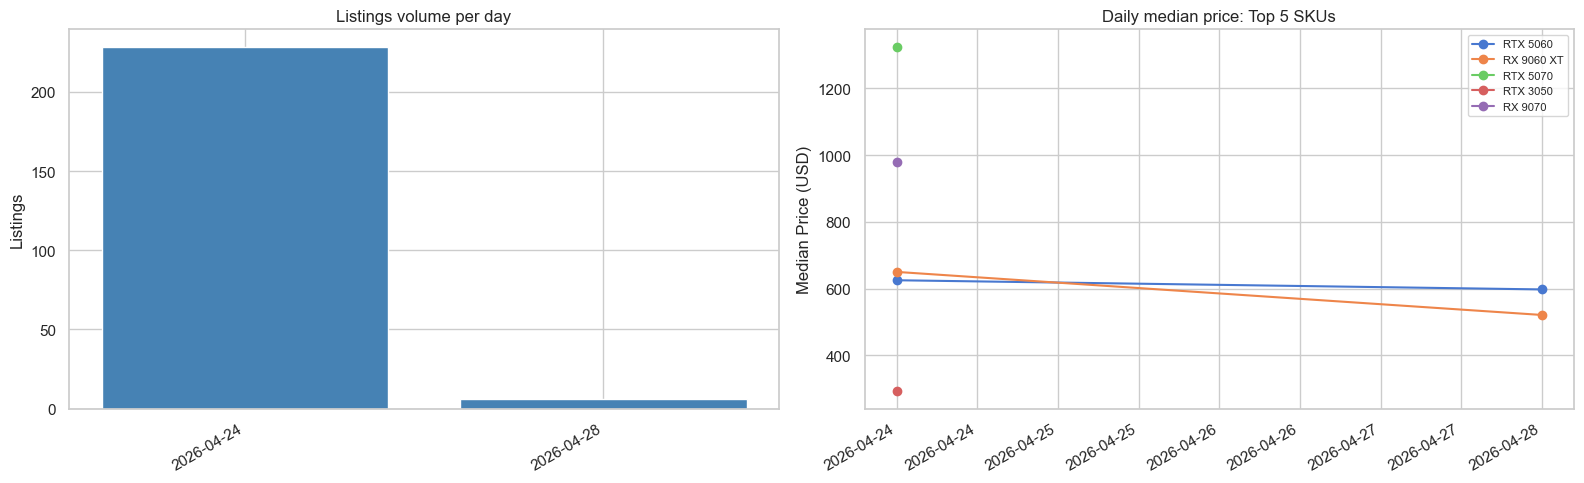

In [42]:
if not HAS_SNAPSHOTS:
    print("⚠️  No price_snapshots available.")
else:
    days_covered = df_snap["run_date"].nunique()
    print(f"Days of history available: {days_covered}")

    if days_covered < 7:
        print("⚠️  Less than 7 days of history. This section will improve with more data.")
        print("     Showing initial trend with available data...")

    # Listings volume per day
    daily_volume = df_snap.groupby("run_date").size().reset_index(name="listings")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].bar(range(len(daily_volume)), daily_volume["listings"], color="steelblue")
    axes[0].set_xticks(range(len(daily_volume)))
    axes[0].set_xticklabels([str(d) for d in daily_volume["run_date"]], rotation=45)
    axes[0].set_title("Listings volume per day")
    axes[0].set_ylabel("Listings")

    # Median daily price for top 5 SKUs
    top5 = df_snap["canonical_product_id"].value_counts().head(5).index
    df_top5 = df_snap[df_snap["canonical_product_id"].isin(top5)]
    daily_price = (
        df_top5.groupby(["run_date", "canonical_product_id"])["price_usd"]
        .median()
        .reset_index()
    )

    for sku in top5:
        subset = daily_price[daily_price["canonical_product_id"] == sku]
        axes[1].plot(subset["run_date"], subset["price_usd"], marker="o", label=sku)

    axes[1].set_title("Daily median price: Top 5 SKUs")
    axes[1].set_ylabel("Median Price (USD)")
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate()
    axes[1].legend(fontsize=8)


    plt.tight_layout()
    plt.show()

---
## Section 7: Price Signals and Market Intelligence
*Requires weeks/months of history - high-value section for portfolio*

In [32]:
if not HAS_SNAPSHOTS:
    print("⚠️  No price_snapshots available.")
else:
    days_covered = df_snap["run_date"].nunique()
    MIN_DAYS_FOR_SIGNALS = 14

    if days_covered < MIN_DAYS_FOR_SIGNALS:
        print(f"⚠️  This section requires at least {MIN_DAYS_FOR_SIGNALS} days of history.")
        print(f"     Currently: {days_covered} day(s). Come back when you have more data.")
        print("\n📌 What this section will calculate when there is sufficient history:")
        print("   - Current price vs historical median by SKU")
        print("   - Current price percentile (is it a good time to buy?)")
        print("   - Rolling median (7/14 days) to smooth volatility")
        print("   - Detection of listings with significantly low prices")
        print("   - Price alerts: 'RTX 4070 is 15% below its historical median'")
    else:
        # --- This section activates automatically with sufficient history ---

        # Current price vs historical median
        latest_date = df_snap["run_date"].max()
        df_latest = df_snap[df_snap["run_date"] == latest_date]
        df_hist = df_snap[df_snap["run_date"] < latest_date]

        hist_median = (
            df_hist.groupby("canonical_product_id")["price_usd"]
            .median()
            .rename("hist_median")
        )
        curr_median = (
            df_latest.groupby("canonical_product_id")["price_usd"]
            .median()
            .rename("curr_median")
        )

        price_signals = pd.concat([hist_median, curr_median], axis=1).dropna()
        price_signals["delta_pct"] = (
            (price_signals["curr_median"] - price_signals["hist_median"])
            / price_signals["hist_median"]
            * 100
        ).round(1)

        print(f"=== Current price vs historical median (reference: {latest_date}) ===")
        display(price_signals.sort_values("delta_pct"))

        # Deal detection: prices > 10% below historical median
        deals = price_signals[price_signals["delta_pct"] < -10]
        if len(deals) > 0:
            print("\n🔥 Possible opportunities (current price > 10% below historical median):")
            display(deals)
        else:
            print("\nNo opportunities detected at this time.")

        # Rolling median for top SKU
        top_sku = df_snap["canonical_product_id"].value_counts().index[0]
        df_rolling = (
            df_snap[df_snap["canonical_product_id"] == top_sku]
            .groupby("run_date")["price_usd"]
            .median()
            .reset_index()
        )
        df_rolling["rolling_7d"] = df_rolling["price_usd"].rolling(7, min_periods=1).mean()

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(df_rolling["run_date"], df_rolling["price_usd"], marker="o", label="Daily price", alpha=0.7)
        ax.plot(df_rolling["run_date"], df_rolling["rolling_7d"], linewidth=2.5, label="Rolling 7d", color="orange")
        ax.set_title(f"Price history: {top_sku}")
        ax.set_ylabel("Price (USD)")
        ax.legend()
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()

⚠️  This section requires at least 14 days of history.
     Currently: 2 day(s). Come back when you have more data.

📌 What this section will calculate when there is sufficient history:
   - Current price vs historical median by SKU
   - Current price percentile (is it a good time to buy?)
   - Rolling median (7/14 days) to smooth volatility
   - Detection of listings with significantly low prices
   - Price alerts: 'RTX 4070 is 15% below its historical median'
